In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.mstats import winsorize
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
df=pd.read_csv("HR_comma_sep.csv")
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [3]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [4]:
df.isna().sum().any()

False

In [5]:
df=df.drop_duplicates()
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
11995,0.90,0.55,3,259,10,1,0,1,management,high
11996,0.74,0.95,5,266,10,0,0,1,management,high
11997,0.85,0.54,3,185,10,0,0,1,management,high
11998,0.33,0.65,3,172,10,0,0,1,marketing,high


In [6]:
df.dtypes

satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
sales                     object
salary                    object
dtype: object

In [7]:
df.describe().loc["mean"]

satisfaction_level         0.629658
last_evaluation            0.716683
number_project             3.802852
average_montly_hours     200.473522
time_spend_company         3.364857
Work_accident              0.154282
left                       0.166041
promotion_last_5years      0.016929
Name: mean, dtype: float64

<Figure size 1200x600 with 0 Axes>

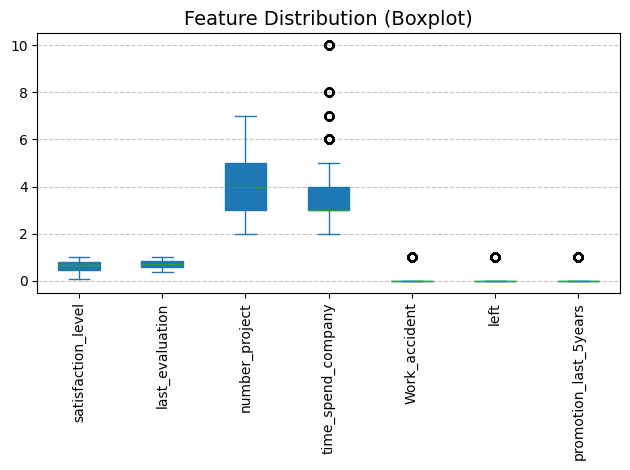

In [8]:

import matplotlib.pyplot as plt

plt.style.use('default')  
plt.figure(figsize=(12, 6))

df.drop(columns="average_montly_hours").plot(kind="box", patch_artist=True)

plt.xticks(rotation=90)
plt.title("Feature Distribution (Boxplot)", fontsize=14)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()


C:\Users\ARYAN\AppData\Local\Temp\ipykernel_21680\2830690634.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["time_spend_company"]=winsorize(df["time_spend_company"],limits=[0,0.1])


<Axes: >

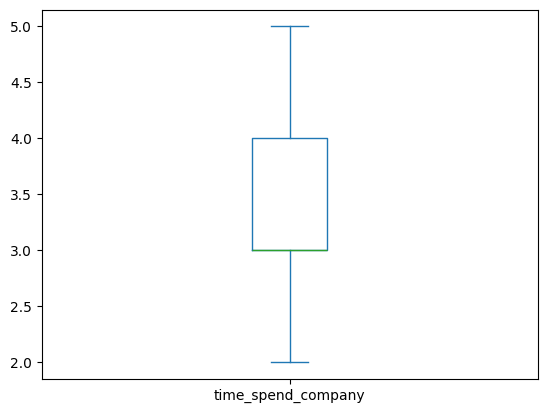

In [9]:

df["time_spend_company"]=winsorize(df["time_spend_company"],limits=[0,0.1])
df["time_spend_company"].plot(kind="box")

<Axes: >

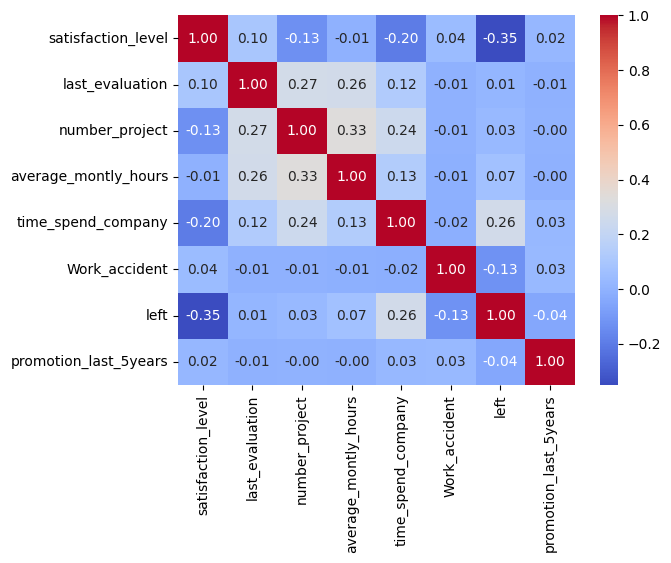

In [10]:

correlation_matrix=df.select_dtypes(include='number').corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

<Axes: xlabel='satisfaction_level', ylabel='Count'>

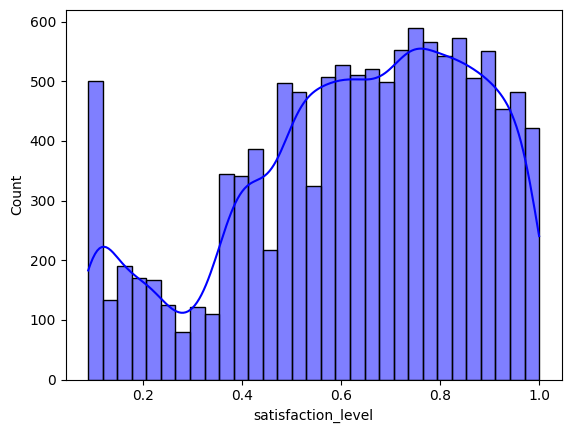

In [11]:
sns.histplot(df['satisfaction_level'], kde=True, color='blue')

<Axes: xlabel='last_evaluation', ylabel='Count'>

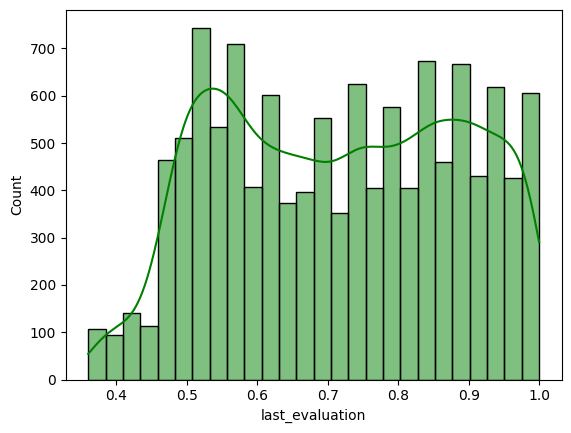

In [12]:
sns.histplot(df['last_evaluation'], kde=True, color='green')

<Axes: xlabel='average_montly_hours', ylabel='Count'>

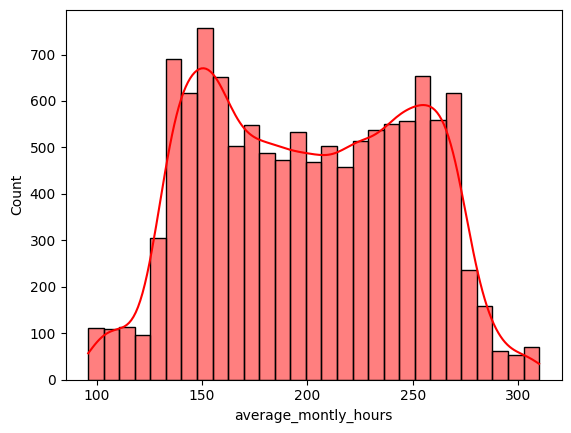

In [13]:
sns.histplot(df['average_montly_hours'], kde=True, color='red')

<Axes: xlabel='number_project'>

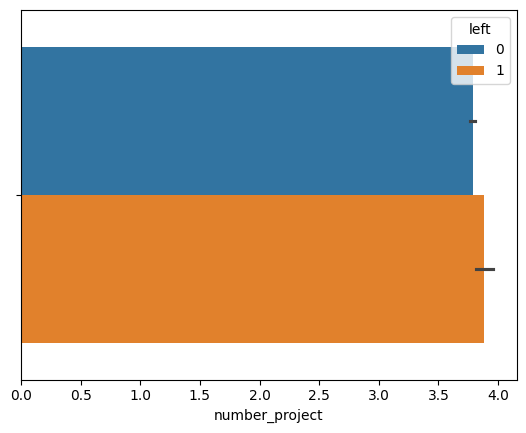

In [14]:
sns.barplot(x='number_project', hue='left', data=df)

<Axes: xlabel='left', ylabel='count'>

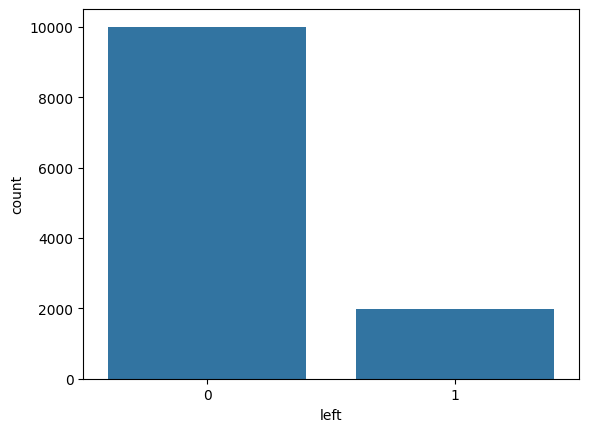

In [15]:
sns.countplot(x='left',data=df)

In [ ]:
num=df.select_dtypes(include=['int64','float64'])
cate=df.select_dtypes(include=['object'])

cate = pd.get_dummies(df[cate.columns], drop_first=True)

df_processed = pd.concat([num, cate], axis=1)

df_processed

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,5,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,0.90,0.55,3,259,5,1,0,1,False,False,False,True,False,False,False,False,False,False,False
11996,0.74,0.95,5,266,5,0,0,1,False,False,False,True,False,False,False,False,False,False,False
11997,0.85,0.54,3,185,5,0,0,1,False,False,False,True,False,False,False,False,False,False,False
11998,0.33,0.65,3,172,5,0,0,1,False,False,False,False,True,False,False,False,False,False,False


In [17]:
X=df_processed.drop('left',axis=1)
y=df_processed['left']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

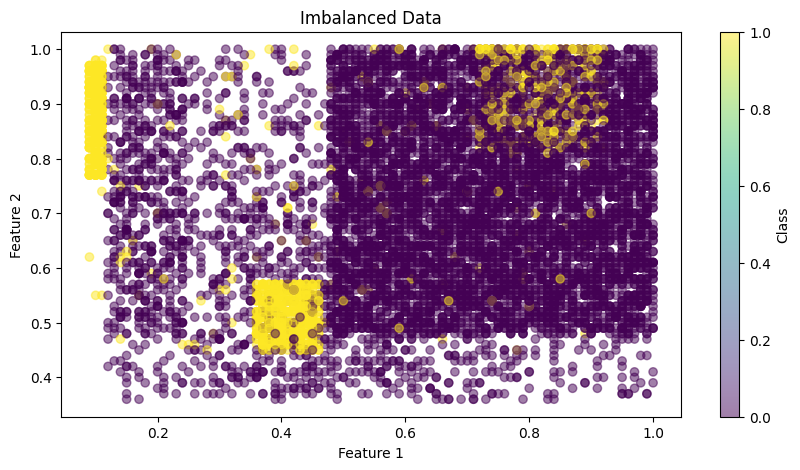

In [18]:
plt.figure(figsize=(10, 5))
plt.scatter(X_train.values[:, 0], X_train.values[:, 1], c=y_train, alpha=0.5, cmap='viridis', marker='o')
plt.title('Imbalanced Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Class')

In [19]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

Text(0, 0.5, 'Feature 2')

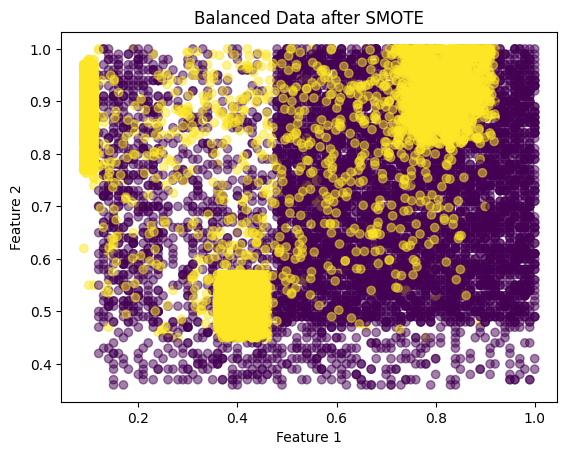

In [20]:
plt.scatter(X_train_smote.values[:, 0], X_train_smote.values[:, 1], c=y_train_smote, alpha=0.5, cmap="viridis", marker='o')
plt.title('Balanced Data after SMOTE')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

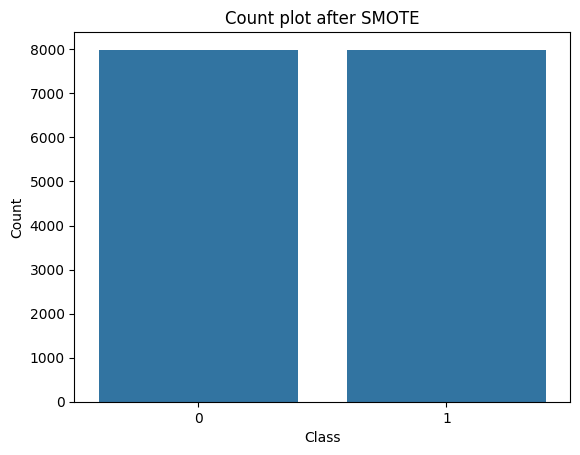

In [21]:
sns.countplot(x=y_train_smote)
plt.title("Count plot after SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [22]:
log_reg=LogisticRegression(max_iter=1000,random_state=42)
log_reg.fit(X_train_smote,y_train_smote)

LogisticRegression(max_iter=1000, random_state=42)

In [23]:
from sklearn.model_selection import cross_val_predict, StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(log_reg, X, y, cv=cv, scoring='accuracy')
scores.mean()

0.8231168741771402

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
y_train_predict=log_reg.predict(X_train_smote)
y_test_predict=log_reg.predict(X_test)
report = classification_report(y_test, y_test_predict, output_dict=True)
print(report)
log_train_acc=accuracy_score(y_train_smote,y_train_predict)
log_test_acc=accuracy_score(y_test,y_test_predict)

{'0': {'precision': 0.932288752098489, 'recall': 0.8292682926829268, 'f1-score': 0.8777660695468915, 'support': 2009.0}, '1': {'precision': 0.4395424836601307, 'recall': 0.6897435897435897, 'f1-score': 0.5369261477045908, 'support': 390.0}, 'accuracy': 0.8065860775323052, 'macro avg': {'precision': 0.6859156178793099, 'recall': 0.7595059412132583, 'f1-score': 0.7073461086257411, 'support': 2399.0}, 'weighted avg': {'precision': 0.8521841065416071, 'recall': 0.8065860775323052, 'f1-score': 0.8223564949247585, 'support': 2399.0}}


In [27]:
print("train accurecccy : ",accuracy_score(y_train_smote,y_train_predict))
print("test acc.......  : ",accuracy_score(y_test,y_test_predict))

train accurecccy :  0.8683518958828682
test acc.......  :  0.8065860775323052


Confusion Matrix:
[[1666  343]
 [ 121  269]]


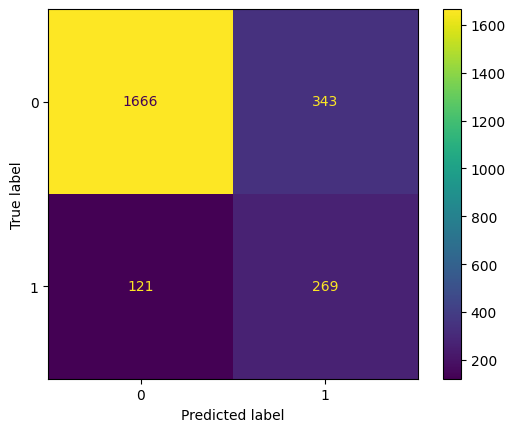

In [28]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import ConfusionMatrixDisplay

conf_matrix = confusion_matrix(y_test, y_test_predict)
print("Confusion Matrix:")
print(conf_matrix)

# Heatmap visualization for confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = ["0", "1"])

# display matrix
cm_display.plot()
plt.show()

In [36]:
predicted_probabilities = log_reg.predict_proba(X_test)[:, 1]

# Create a dataframe to store the actual labels, predicted labels, and predicted probabilities
results_df = pd.DataFrame({
    'Actual Label': y_test,
    'Predicted Label': y_test_predict,  # Assuming y_test_predict is the predicted labels from the model
    'Predicted Probability': predicted_probabilities
})

# Display the first 5 instances in the result dataframe
print(results_df.head())

      Actual Label  Predicted Label  Predicted Probability
6816             0                0               0.087424
4649             0                1               0.683511
3169             0                0               0.184994
6485             0                0               0.228305
9388             0                1               0.719035


Optimal Threshold: 0.3196


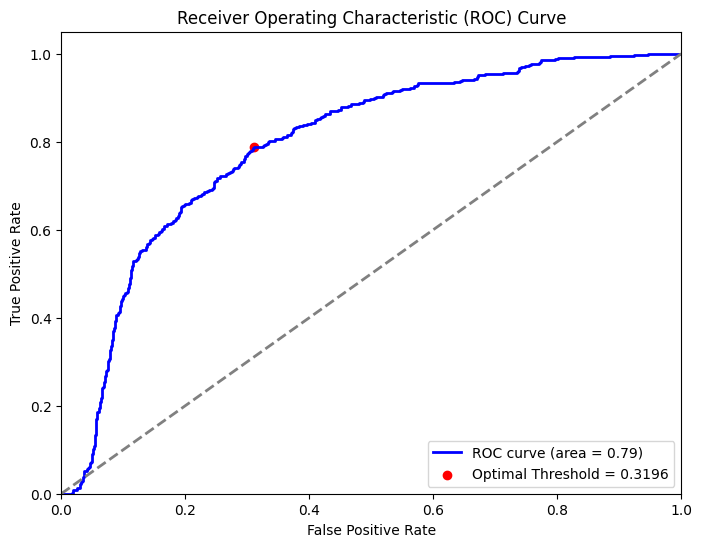

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import ConfusionMatrixDisplay
# Compute the false positive rate (fpr), true positive rate (tpr), and thresholds for different thresholds
fpr, tpr, thresholds = roc_curve(y_test, predicted_probabilities)

# Compute the Area Under the Curve (AUC) for the ROC curve
roc_auc = auc(fpr, tpr)

# Compute Youden's J statistic for each threshold
youden_j = tpr - fpr
optimal_threshold_index = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_threshold_index]

print(f"Optimal Threshold: {optimal_threshold:.4f}")

# Plot the ROC curve with the optimal threshold marked
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.scatter(fpr[optimal_threshold_index], tpr[optimal_threshold_index], color='red', marker='o', label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [31]:
from sklearn.ensemble import RandomForestClassifier

In [32]:
rf_model = RandomForestClassifier(random_state=123)
rf_model.fit(X_train_smote, y_train_smote)

RandomForestClassifier(random_state=123)

In [33]:

# Predict on testing set
y_train_pred_rf=rf_model.predict(X_train_smote)
y_test_pred_rf = rf_model.predict(X_test)
y_pred_prob_rf = rf_model.predict_proba(X_test)

In [34]:
# Determine the class order
class_order = rf_model.classes_
print("Class order:", class_order)

# Create a DataFrame to display actual and predicted labels with probabilities
results_df = pd.DataFrame({
    'Actual Label': y_test,
    'Predicted Label': y_test_pred_rf,
})

# Add predicted probabilities with correct class names
for i, class_name in enumerate(class_order):
    results_df[f'Predicted Probability {class_name}'] = np.round(y_pred_prob_rf[:, i], 2)

# Display the first few rows of the results DataFrame
results_df.head()
rf_train_acc=accuracy_score(y_train_smote,y_train_pred_rf)
rf_test_acc=accuracy_score(y_test,y_test_pred_rf)

Class order: [0 1]


In [35]:
print("train accurecccy : ",accuracy_score(y_train_smote,y_train_pred_rf))
print("test acc.......  : ",accuracy_score(y_test,y_test_pred_rf))

train accurecccy :  1.0
test acc.......  :  0.9791579824927052


Confusion Matrix:
[[1990   19]
 [  31  359]]


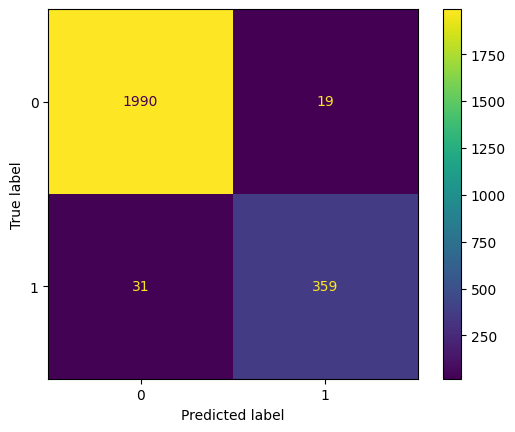

In [36]:
conf_matrix = confusion_matrix(y_test, y_test_pred_rf)
print("Confusion Matrix:")
print(conf_matrix)

# Heatmap visualization for confusion matrix
cm_display = ConfusionMatrixDisplay(confusion_matrix = conf_matrix, display_labels = ["0", "1"])

# display matrix
cm_display.plot()
plt.show()

Optimal Threshold: 0.4600


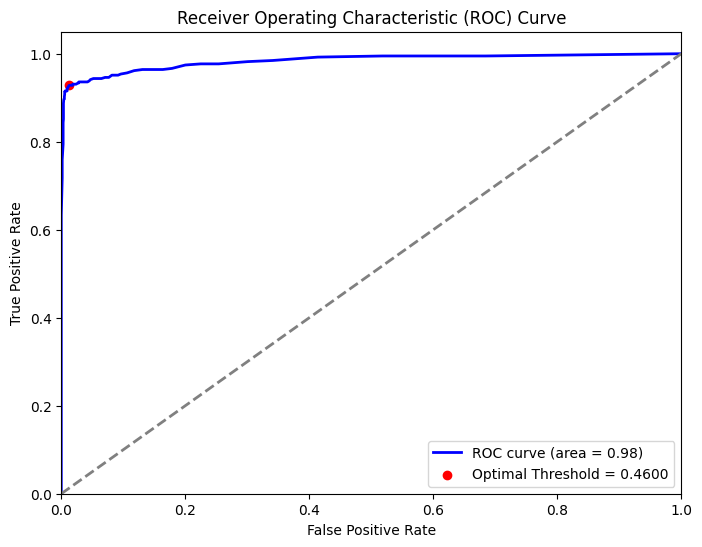

In [37]:
# Compute the false positive rate (fpr), true positive rate (tpr), and thresholds for different thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_rf[:,1])

# Compute the Area Under the Curve (AUC) for the ROC curve
roc_auc = auc(fpr, tpr)

# Compute Youden's J statistic for each threshold
youden_j = tpr - fpr
optimal_threshold_index = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_threshold_index]

print(f"Optimal Threshold: {optimal_threshold:.4f}")

# Plot the ROC curve with the optimal threshold marked
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.scatter(fpr[optimal_threshold_index], tpr[optimal_threshold_index], color='red', marker='o', label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [38]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import KFold

In [39]:
gbc=GradientBoostingClassifier(n_estimators=1000,random_state=7)
kfold = KFold(n_splits=5, random_state=7, shuffle=True)

gb_results = cross_val_score(gbc, X_train_smote, y_train_smote, cv=kfold)
print("Gradient Boosting Classifier mean accuracy after cross validation: ", gb_results.mean())

Gradient Boosting Classifier mean accuracy after cross validation:  0.9791639768666103


In [40]:
gbc.fit(X_train_smote, y_train_smote)

GradientBoostingClassifier(n_estimators=1000, random_state=7)

In [41]:
# Fit the Gradient boosting Classifier pipeline on the training set and evaluate on the test set

gb_boost_train_score = gbc.score(X_train_smote, y_train_smote)
gb_boost_test_score = gbc.score(X_test, y_test)
print("Gradient Boosting Classifier train accuracy: ", gb_boost_train_score)
print("Gradient Boosting Classifier test accuracy: ", gb_boost_test_score)

Gradient Boosting Classifier train accuracy:  0.994055812789388
Gradient Boosting Classifier test accuracy:  0.9758232596915382


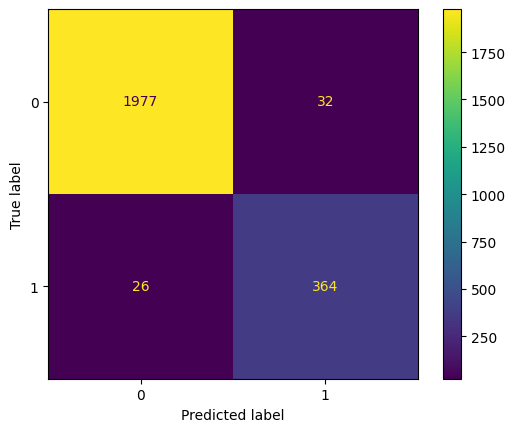

In [42]:
cm = confusion_matrix(y_test,gbc.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0','1'])
disp.plot()
plt.show()

Optimal Threshold: 0.4979


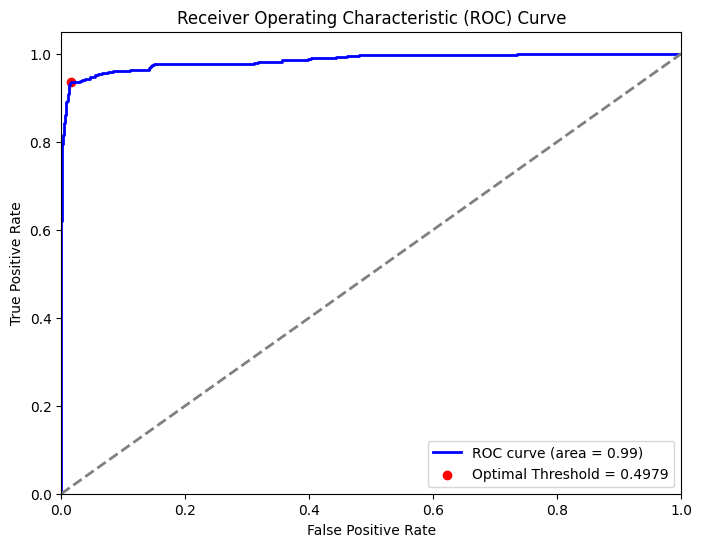

In [43]:
# Compute the false positive rate (fpr), true positive rate (tpr), and thresholds for different thresholds
y_test_pred_prob_gbc=gbc.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_prob_gbc[:,1])

# Compute the Area Under the Curve (AUC) for the ROC curve
roc_auc = auc(fpr, tpr)

# Compute Youden's J statistic for each threshold
youden_j = tpr - fpr
optimal_threshold_index = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_threshold_index]

print(f"Optimal Threshold: {optimal_threshold:.4f}")

# Plot the ROC curve with the optimal threshold marked
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.scatter(fpr[optimal_threshold_index], tpr[optimal_threshold_index], color='red', marker='o', label=f'Optimal Threshold = {optimal_threshold:.4f}')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [44]:
y_pred_prob_rf[:,1]

array([0.04, 0.  , 0.2 , ..., 0.09, 0.12, 0.02])

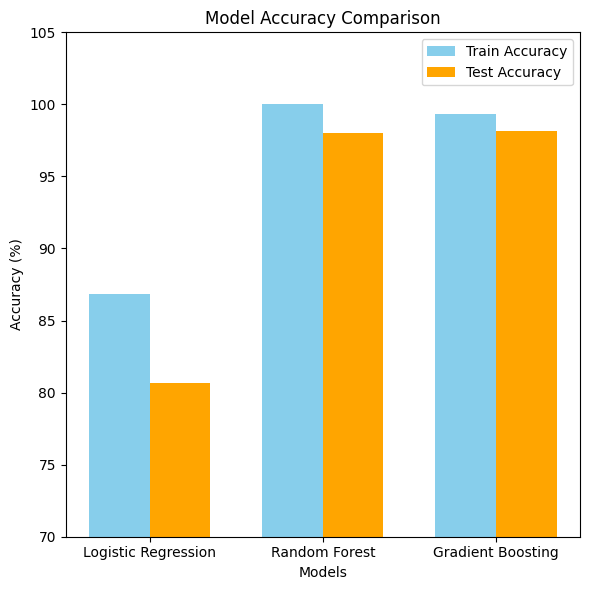

In [48]:

models = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']

train_accuracy = [log_train_acc, rf_train_acc, gb_boost_train_score]
test_accuracy = [log_test_acc, rf_test_acc, gb_boost_test_score]

bar_width = 0.35
r1 = range(len(models))
r2 = [x + bar_width for x in r1]

plt.figure(figsize=(6, 6))
plt.bar(r1, train_accuracy, width=bar_width, label='Train Accuracy', color='skyblue')
plt.bar(r2, test_accuracy, width=bar_width, label='Test Accuracy', color='orange')

plt.xlabel('Models')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.xticks([r + bar_width / 2 for r in range(len(models))], models)
plt.ylim(70, 105)
plt.legend()

plt.tight_layout()
plt.show()
